In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
#scaling, normalization
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer

#kmeans, dbscan, hierarchical (sklearn)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
#evaluation
from sklearn.metrics import silhouette_score
#import dataset
from sklearn.datasets import load_iris

from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import CountVectorizer

#distance matrix (dbscan elbow, hierarchical)
from scipy.spatial.distance import pdist, squareform

# hierarchical (scipy)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import pycountry
from collections import Counter
import ast

from scipy.stats import pearsonr

In [2]:
df = pd.read_csv('train.csv') 
df_backup = df.copy()

In [3]:
df.head()

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,titleType,awardNominationsExcludeWins,canHaveEpisodes,isRatable,isAdult,numRegions,userReviewsTotal,ratingCount,countryOfOrigin,genres
0,Neogenic Nightmare Chapter 3: Hydro-Man,"(7, 8]",1995,\N,\N,0.0,779,1,10,1,...,tvEpisode,0,False,True,0,1,0,781,['US'],"Action,Adventure,Animation"
1,Looping,"(5, 6]",1982,\N,\N,0.0,11,1,10,1,...,videoGame,0,False,True,0,1,0,11,['XWG'],Action
2,Idealnaya para,"(5, 6]",1992,\N,\N,0.0,38,1,10,1,...,movie,0,False,True,0,1,1,38,['RU'],Comedy
3,MasterChef Celebrity México,"(5, 6]",2021,\N,\N,0.0,15,1,10,22,...,tvSeries,0,True,True,0,1,0,15,['MX'],Reality-TV
4,Seutateueob,"(7, 8]",2020,2020,80,1.0,15718,1,10,347,...,tvSeries,1,True,True,0,32,452,15746,['KR'],"Comedy,Drama,Romance"


In [4]:
df.tail()

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,titleType,awardNominationsExcludeWins,canHaveEpisodes,isRatable,isAdult,numRegions,userReviewsTotal,ratingCount,countryOfOrigin,genres
16426,Caprices,"(5, 6]",1942,\N,\N,0.0,73,1,10,4,...,movie,0,False,True,0,14,4,73,['FR'],Comedy
16427,Haar Jeet,"(4, 5]",1990,\N,\N,0.0,15,1,10,2,...,movie,0,False,True,0,1,1,15,['IN'],"Action,Drama,Thriller"
16428,Kotigobba 3,"(5, 6]",2021,\N,140,0.0,2560,1,10,39,...,movie,5,False,True,0,5,49,2560,['IN'],"Action,Drama,Romance"
16429,Ator l'invincibile,"(3, 4]",1982,\N,\N,0.0,3011,1,10,52,...,movie,0,False,True,0,26,58,3012,['IT'],"Action,Adventure,Fantasy"
16430,Anniversary Night,"(9, 10]",2022,\N,\N,0.0,9,1,10,7,...,short,0,False,True,0,1,0,9,['IN'],"Drama,Short"


In [5]:
df["isAdult"] = df["isAdult"].astype(bool)
df['genres'] = df['genres'].replace('\\N', np.nan)
df['awardWins'] = df['awardWins'].replace('\\N', np.nan)
df['endYear'] = df['endYear'].replace('\\N', np.nan)
df['runtimeMinutes'] = df['runtimeMinutes'].replace('\\N', np.nan)
df['endYear'] = df['endYear'].dropna().astype(int)


In [6]:
df.dtypes

originalTitle                   object
rating                          object
startYear                        int64
endYear                        float64
runtimeMinutes                  object
awardWins                      float64
numVotes                         int64
worstRating                      int64
bestRating                       int64
totalImages                      int64
totalVideos                      int64
totalCredits                     int64
criticReviewsTotal               int64
titleType                       object
awardNominationsExcludeWins      int64
canHaveEpisodes                   bool
isRatable                         bool
isAdult                           bool
numRegions                       int64
userReviewsTotal                 int64
ratingCount                      int64
countryOfOrigin                 object
genres                          object
dtype: object

In [7]:

numeric_cols = ['startYear', 'endYear', 'runtimeMinutes', 'awardWins', 
                     'numVotes', 'totalImages', 'totalVideos', 'totalCredits','criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 
                      'userReviewsTotal', 'ratingCount']


# Convert columns to numeric, handling non-numeric values
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
startYear,16431.0,1991.867081,26.120690,1878.0,1978.0,1997.0,2013.0,2024.0
endYear,814.0,2001.574939,18.449257,1945.0,1989.0,2005.5,2018.0,2025.0
runtimeMinutes,11579.0,61.222644,52.110187,0.0,25.0,58.0,90.0,3000.0
awardWins,13813.0,0.491855,2.974264,0.0,0.0,0.0,0.0,145.0
numVotes,16431.0,1492.153551,20137.708096,5.0,15.0,36.0,148.5,966565.0
worstRating,16431.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
bestRating,16431.0,10.000000,0.000000,10.0,10.0,10.0,10.0,10.0
totalImages,16431.0,11.477025,74.254261,0.0,1.0,1.0,6.0,3504.0
totalVideos,16431.0,0.271499,3.115448,0.0,0.0,0.0,0.0,258.0
totalCredits,16431.0,61.341976,174.017450,0.0,16.0,34.0,65.0,15742.0


In [9]:
df_to_save = df.describe(include="all").transpose()
float_cols = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
df_to_save[float_cols] = df_to_save[float_cols].astype(float)
df_to_save['count'] = df_to_save['count'].astype(int)
df_to_save.to_csv("tab.csv", decimal=",", sep=";", float_format="%.2f", na_rep="-")

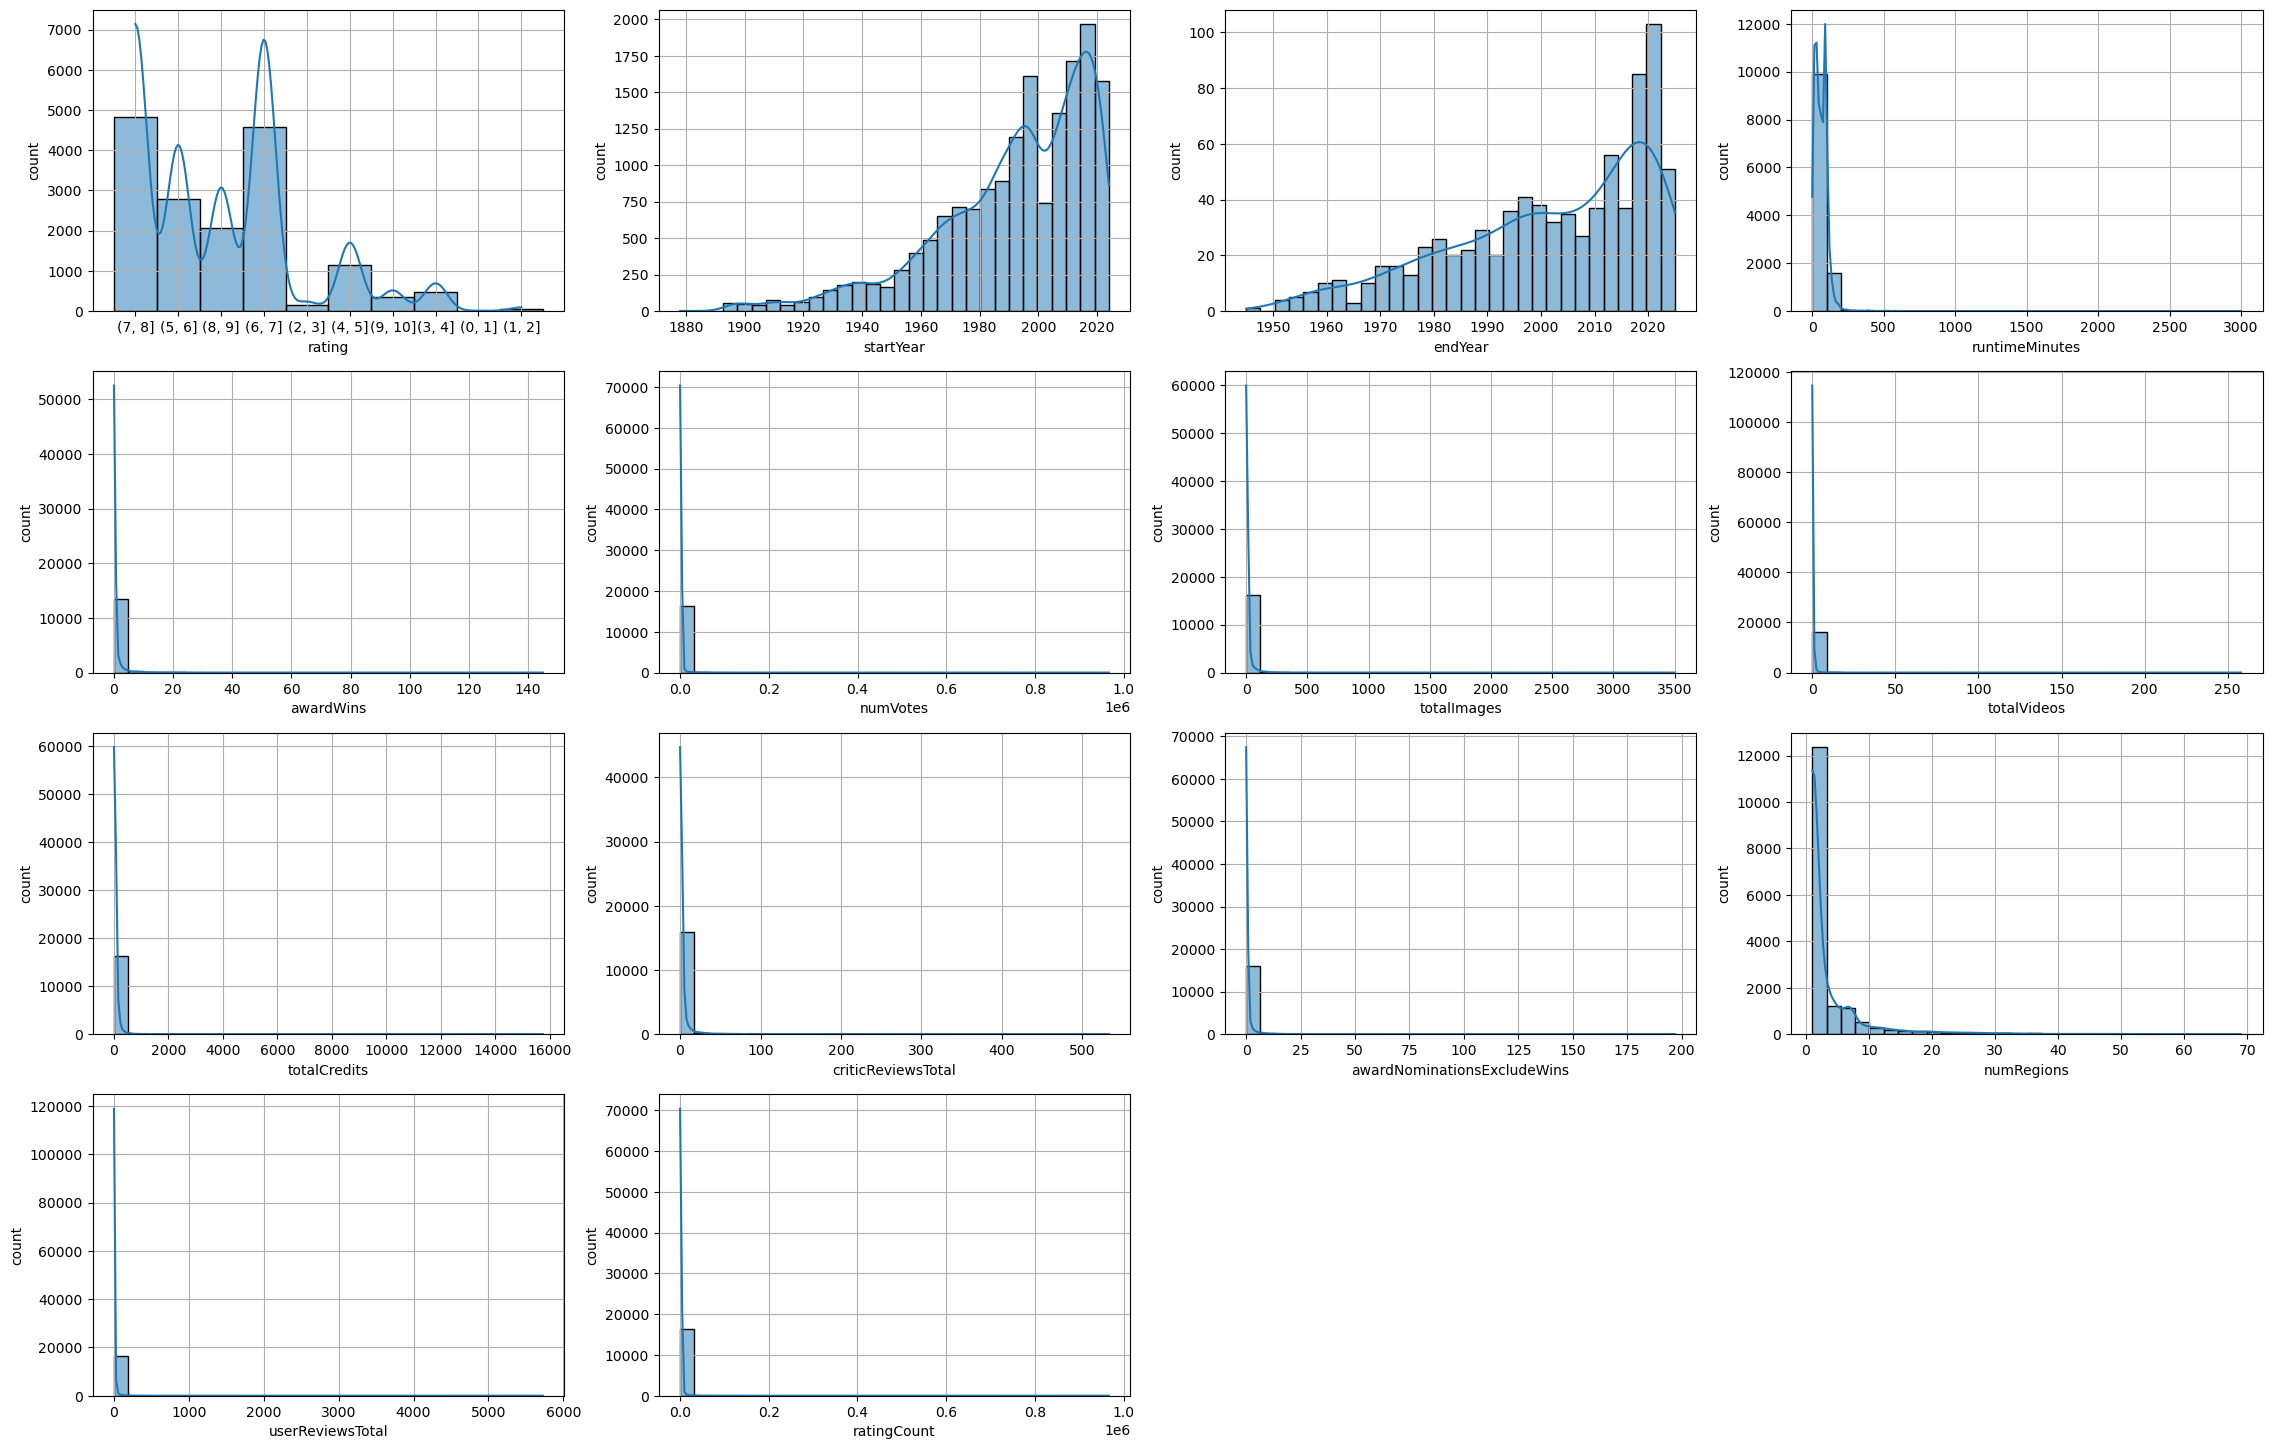

In [10]:
variables = ['rating','startYear', 'endYear', 'runtimeMinutes', 'awardWins', 
                     'numVotes', 'totalImages', 'totalVideos', 'totalCredits','criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 
                      'userReviewsTotal', 'ratingCount']

# Loop through each column to plot histogram and box plot
plt.figure(figsize=(28, 18))
for i, col in enumerate(variables):
    plt.subplot(4, 4, i+1)

    # Histogram with KDE (Kernel Density Estimate)
    sns.histplot(df[col], kde=True, bins=30)
    # plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.grid(True)




BoxPlot for numerical variables

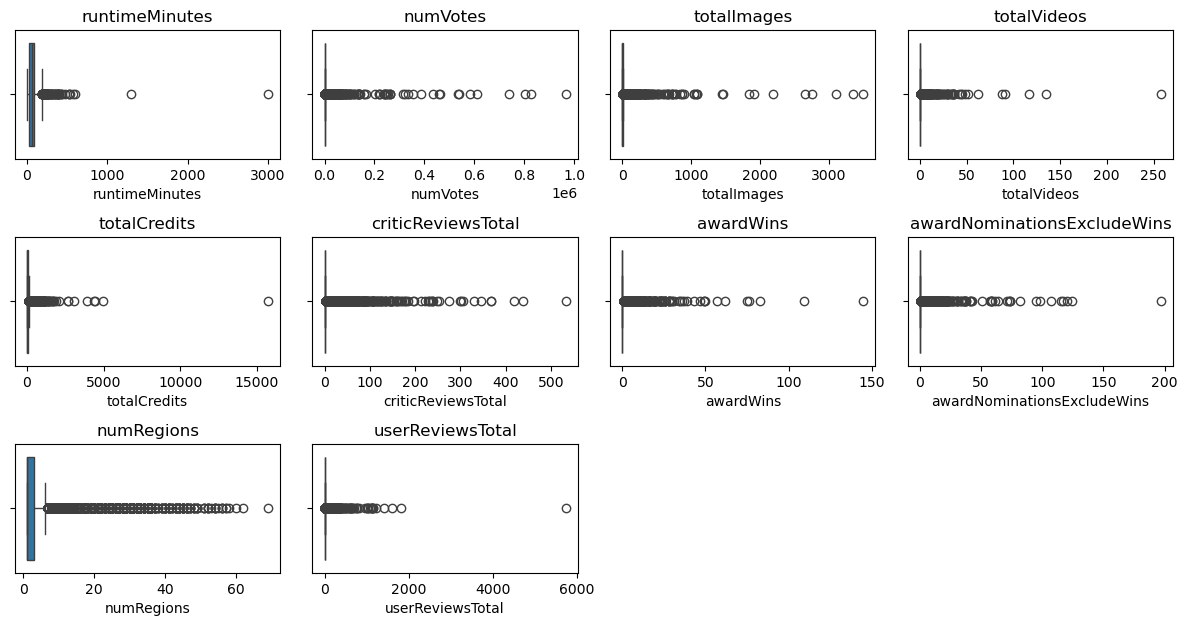

In [11]:

numeric_cols = ['runtimeMinutes', 'numVotes', 'totalImages', 'totalVideos', 
                     'totalCredits', 'criticReviewsTotal', 'awardWins', 
                     'awardNominationsExcludeWins', 'numRegions', 'userReviewsTotal', 
                   ]

# Set up the figure for multiple subplots, adjusting height based on the number of columns
plt.figure(figsize=(12, 8))  # Adjust the figure height based on the number of variables

# Loop through each numerical column to create box plots
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i+1)
    
    # Plot the box plot
    sns.boxplot(x=df[col])
    plt.title(f'{col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

In [12]:
# Drop rows with runtimeMinutes > 1000
df = df.drop(df[df['runtimeMinutes'] > 1000].index)
df = df.drop(df[df['runtimeMinutes'] == 0].index)
# Drop rows with awardWins > 100
df = df.drop(df[df['awardWins'] > 100].index)
# Drop rows with awardNominations > 150
df = df.drop(df[df['awardNominationsExcludeWins'] > 150].index)
# Drop rows with totalCredits > 6000
df = df.drop(df[df['totalCredits'] > 6000].index)
# Drop rows with userReviewsTotal > 2000
df = df.drop(df[df['userReviewsTotal'] > 2000].index)
# Drop rows with totalVideos > 2000
df = df.drop(df[df['totalVideos'] > 150].index)

In [13]:
df.shape

(16423, 23)

In [14]:
df[df.titleType == 'tvSeries']['runtimeMinutes']

3          NaN
4         80.0
20        30.0
42         NaN
51         NaN
         ...  
16349    180.0
16375     24.0
16388      NaN
16405      NaN
16407     60.0
Name: runtimeMinutes, Length: 1370, dtype: float64

Bar charts for categorical variables

In [15]:
df.genres.unique()

array(['Action,Adventure,Animation', 'Action', 'Comedy', 'Reality-TV',
       'Comedy,Drama,Romance', 'Documentary,Short', 'Drama,Romance',
       'Animation,Short', 'Drama', 'Sport', 'Family', 'Comedy,Romance',
       'Short', 'Comedy,Short', 'Crime,Drama,Mystery', 'Drama,Western',
       'Crime', 'Drama,History,War', 'Western', 'Drama,Mystery', nan,
       'Crime,Drama,Romance', 'Crime,Drama', 'Adult,Short',
       'Family,Game-Show', 'Talk-Show', 'Adventure,Comedy,Short',
       'Action,Crime', 'Action,Adventure,Crime', 'Comedy,Family',
       'Game-Show', 'Crime,Thriller', 'Adult', 'Drama,Sci-Fi,Thriller',
       'Documentary', 'Drama,Thriller', 'Drama,Short',
       'Reality-TV,Romance', 'Action,Adventure,Family',
       'Fantasy,Horror,Short', 'Family,Music', 'Drama,Fantasy',
       'Comedy,Drama,Mystery', 'Adventure,Animation,Comedy',
       'Action,Crime,Documentary', 'Comedy,Reality-TV',
       'Family,Fantasy,Music', 'Comedy,Drama,Thriller',
       'Comedy,Drama,Short', 'Horr

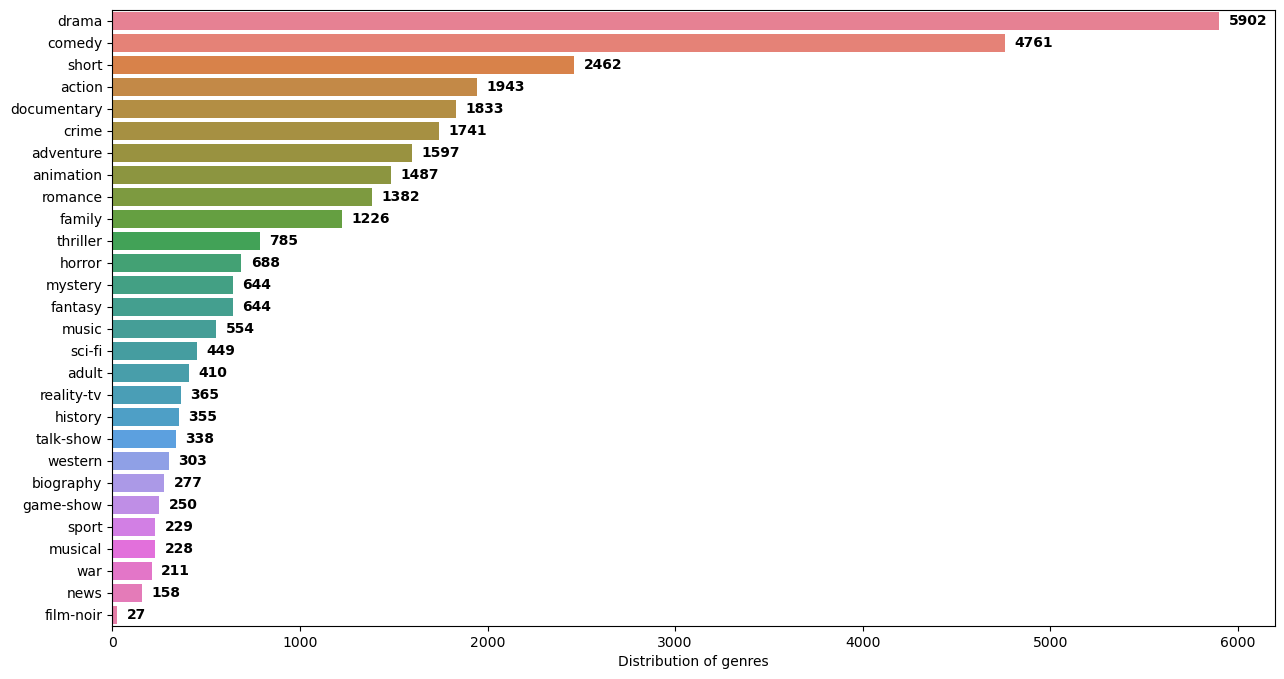

In [16]:
temp = df.genres.dropna()
vec = CountVectorizer(token_pattern='(?u)\\b[\\w-]+\\b', analyzer='word').fit(temp)
bag_of_genres = vec.transform(temp)
unique_genres = vec.get_feature_names_out()

# Create DataFrame from the bag-of-words matrix
genres = pd.DataFrame(bag_of_genres.todense(), columns=unique_genres, index=temp.index)

# Calculate the total number of films for each genre
sorted_genres_count = genres.sum().sort_values(ascending=False)

# Set color palette
colors = sns.color_palette("husl", len(sorted_genres_count))  # 'husl' palette for vibrant colors

# Plotting
plt.figure(figsize=(15, 8))
sns.barplot(x=sorted_genres_count.values, y=sorted_genres_count.index, palette=colors, hue=sorted_genres_count.index, dodge=False, orient="h", legend=False)
plt.xlabel("Distribution of genres")

# Add number labels to each bar
for i, count in enumerate(sorted_genres_count.values):
    plt.text(count + 50, i, f"{count:.0f}", va="center", color="black", fontweight="bold")  # Adjust position and style as needed

# Remove y-axis label
plt.ylabel('') 
# Show plot
plt.show()

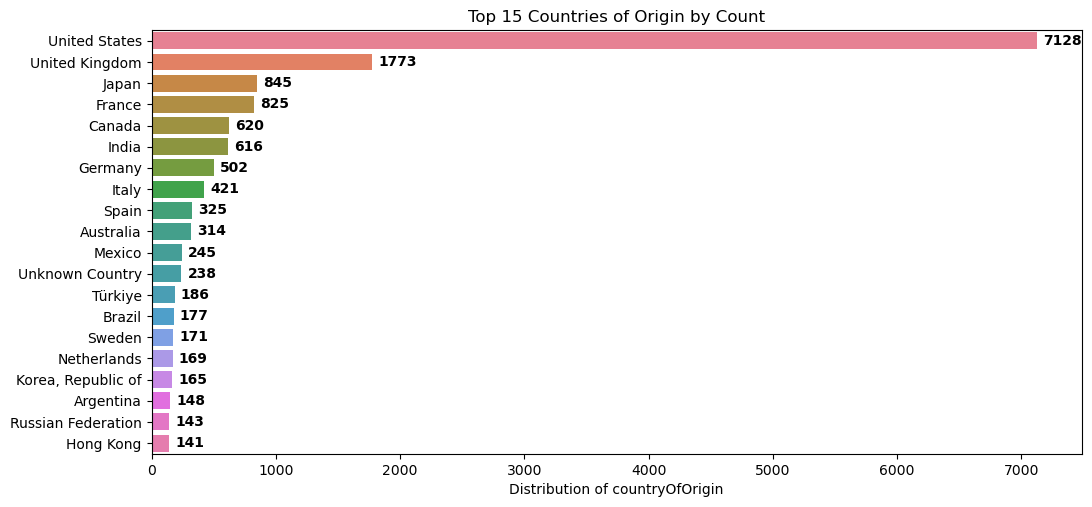

In [17]:
# Step 1: Convert the 'countryOfOrigin' column from string representation of lists to actual lists
df['countryOfOrigin'] = df['countryOfOrigin'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Flatten the list of country codes and count occurrences
all_countries = [country for sublist in df['countryOfOrigin'].dropna() for country in sublist]
country_counts = pd.Series(Counter(all_countries))

# Drop unneeded country codes if present
country_counts = country_counts.drop(["XWW", "XWG"], errors='ignore')

# Step 3: Sort the country counts and get the top 15 countries
top_15_countries = country_counts.nlargest(20)

# Convert country codes to country names
country_names = [
    pycountry.countries.get(alpha_2=coun).name if pycountry.countries.get(alpha_2=coun) else "Unknown Country"
    for coun in top_15_countries.index
]
counts = top_15_countries.values

plt.figure(figsize=(12, 5.5))
colors = sns.color_palette("husl", len(country_names))
sns.barplot(x=counts, y=country_names, palette=colors, hue=country_names, dodge=False, orient="h", legend=False)

# Add labels to each bar
for i, count in enumerate(counts):
    plt.text(count + 50, i, count, va="center", color="black", fontweight="bold")  # Adjust label position if needed

plt.xlabel("Distribution of countryOfOrigin")
plt.ylabel("")  # Remove y-axis label for clarity
plt.title("Top 15 Countries of Origin by Count")
plt.show()

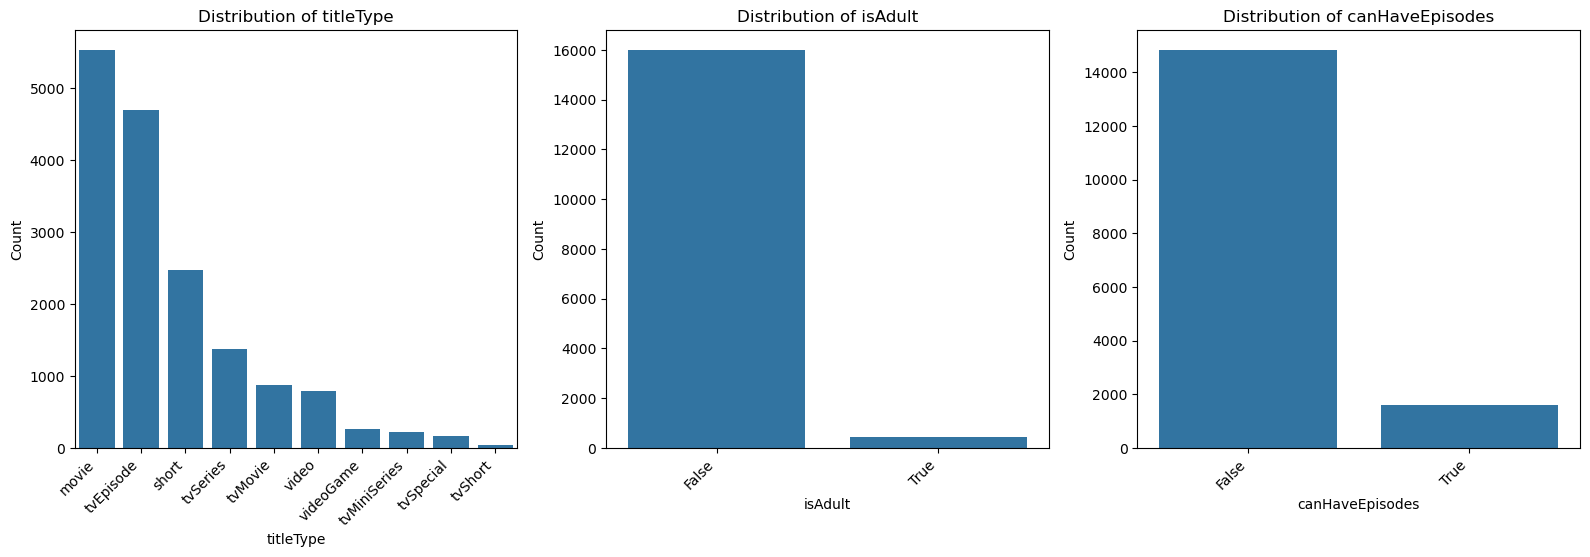

In [18]:
# List of categorical columns to plot
categorical_cols = ['titleType', 'isAdult', 'canHaveEpisodes']

# Set up the figure size based on the number of columns
plt.figure(figsize=(16, 10))  # Adjust figure height based on the number of variables

# Loop through each categorical column to create bar charts
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    
    # Count the frequency of each category in the column
    category_counts = df[col].value_counts().head(15) # Show only top 10 categories if there are too many unique values
    
    # Plot the bar chart
    sns.barplot(x=category_counts.index, y=category_counts.values)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability

plt.tight_layout()
plt.show()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16423 entries, 0 to 16430
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16423 non-null  object 
 1   rating                       16423 non-null  object 
 2   startYear                    16423 non-null  int64  
 3   endYear                      812 non-null    float64
 4   runtimeMinutes               11571 non-null  float64
 5   awardWins                    13806 non-null  float64
 6   numVotes                     16423 non-null  int64  
 7   worstRating                  16423 non-null  int64  
 8   bestRating                   16423 non-null  int64  
 9   totalImages                  16423 non-null  int64  
 10  totalVideos                  16423 non-null  int64  
 11  totalCredits                 16423 non-null  int64  
 12  criticReviewsTotal           16423 non-null  int64  
 13  titleType            

Missing values percentages

In [20]:
missing_percentage = df.isnull().mean() * 100

# Filter to show only the specified columns
missing_percentage[['endYear', 'runtimeMinutes', 'awardWins', 'genres']]

endYear           95.055715
runtimeMinutes    29.543932
awardWins         15.934969
genres             2.326006
dtype: float64

Filling missing values

In [21]:

df['awardWins']= df['awardWins'].fillna(0).astype(int)


In [22]:
df['awardWins'].value_counts()

awardWins
0     14586
1       859
2       354
3       173
4       116
5        74
7        43
6        36
8        29
9        20
10       20
11       16
12       14
13        7
16        6
14        6
17        5
15        5
24        5
19        5
26        5
20        5
28        4
23        4
18        3
21        2
49        2
30        2
50        1
83        1
37        1
35        1
43        1
36        1
76        1
22        1
34        1
31        1
62        1
75        1
29        1
25        1
39        1
57        1
47        1
Name: count, dtype: int64

In [23]:
# Calculate the median runtime for each titleType
median_runtime_by_title = df.groupby('titleType')['runtimeMinutes'].transform('median')

# Fill missing values in runtimeMinutes with the median value of each titleType
df['runtimeMinutes'] = df['runtimeMinutes'].fillna(median_runtime_by_title)

# Verify result
print(df[['titleType', 'runtimeMinutes']])

       titleType  runtimeMinutes
0      tvEpisode            40.0
1      videoGame            28.0
2          movie            90.0
3       tvSeries            30.0
4       tvSeries            80.0
...          ...             ...
16426      movie            90.0
16427      movie            90.0
16428      movie           140.0
16429      movie            90.0
16430      short            12.0

[16423 rows x 2 columns]


In [24]:
df.runtimeMinutes.unique()

array([ 40.,  28.,  90.,  30.,  80.,  34.,  45.,  60.,  12.,  44.,  82.,
        21., 122.,  17.,   1.,  23.,  93.,  57.,  74.,  85.,  83.,  75.,
        78., 184.,  76.,  25.,  10., 108.,  98.,  86., 110.,  48.,  50.,
        89.,  42.,  71.,  79.,   4.,  43.,  41.,   6., 101.,  77.,  14.,
        16.,   7.,  24.,   3., 105.,  20.,   8.,  49.,  29.,  26.,  22.,
       143.,  11.,  47.,  97.,  46.,  65.,  94.,  62.,  51., 100.,  27.,
        35.,  95., 103.,  72.,  18.,  69.,  39.,  87.,  99.,  59.,  64.,
        96.,  68.,  15., 185.,  67., 126., 118., 104., 114.,  91.,  88.,
       106., 137.,  66., 240., 117.,  70.,  32., 120., 115., 142.,  73.,
        58., 111.,   9., 134., 128.,  13.,  52., 102.,  55., 109., 139.,
       107., 528.,   2.,  53.,  92.,  31., 166.,   5.,  19.,  56., 180.,
       146., 132., 220.,  81., 173., 300.,  54., 123., 168.,  84.,  36.,
       155., 153., 119.,  63., 178., 130., 149., 175., 165., 600., 113.,
       112., 140., 169.,  33., 133., 420., 131., 12

In [25]:
df['runtimeMinutes'].value_counts()

runtimeMinutes
90.0     1670
40.0     1535
30.0     1326
60.0      755
12.0      684
         ... 
520.0       1
221.0       1
570.0       1
438.0       1
208.0       1
Name: count, Length: 240, dtype: int64

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16423 entries, 0 to 16430
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16423 non-null  object 
 1   rating                       16423 non-null  object 
 2   startYear                    16423 non-null  int64  
 3   endYear                      812 non-null    float64
 4   runtimeMinutes               16423 non-null  float64
 5   awardWins                    16423 non-null  int32  
 6   numVotes                     16423 non-null  int64  
 7   worstRating                  16423 non-null  int64  
 8   bestRating                   16423 non-null  int64  
 9   totalImages                  16423 non-null  int64  
 10  totalVideos                  16423 non-null  int64  
 11  totalCredits                 16423 non-null  int64  
 12  criticReviewsTotal           16423 non-null  int64  
 13  titleType            

In [27]:
# Step 1: Calculate the mode of 'genres' for each 'titleType'
mode_genres_by_titleType = (
    df.groupby('titleType')['genres']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .to_dict()
)

# Step 2: Fill NA values in 'genres' using the mode for the corresponding 'titleType'
df['genres'] = df.apply(
    lambda row: mode_genres_by_titleType[row['titleType']] 
    if pd.isna(row['genres']) else row['genres'], 
    axis=1
)

In [28]:
df.genres.value_counts


<bound method IndexOpsMixin.value_counts of 0        Action,Adventure,Animation
1                            Action
2                            Comedy
3                        Reality-TV
4              Comedy,Drama,Romance
                    ...            
16426                        Comedy
16427         Action,Drama,Thriller
16428          Action,Drama,Romance
16429      Action,Adventure,Fantasy
16430                   Drama,Short
Name: genres, Length: 16423, dtype: object>

Statistics of nummeric variables after filling missing values

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
startYear,16423.0,1991.862084,26.121964,1878.0,1978.0,1997.0,2013.0,2024.0
endYear,812.0,2001.567734,18.465393,1945.0,1989.0,2005.5,2018.0,2025.0
runtimeMinutes,16423.0,58.190830,39.284706,1.0,29.0,50.0,90.0,600.0
awardWins,16423.0,0.396274,2.333834,0.0,0.0,0.0,0.0,83.0
numVotes,16423.0,1453.016197,19622.097782,5.0,15.0,36.0,148.0,966565.0
worstRating,16423.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
bestRating,16423.0,10.000000,0.000000,10.0,10.0,10.0,10.0,10.0
totalImages,16423.0,11.366985,73.764500,0.0,1.0,1.0,6.0,3504.0
totalVideos,16423.0,0.245022,2.172951,0.0,0.0,0.0,0.0,135.0
totalCredits,16423.0,60.069598,119.715045,0.0,16.0,34.0,65.0,4973.0


Histogram after filling missing values

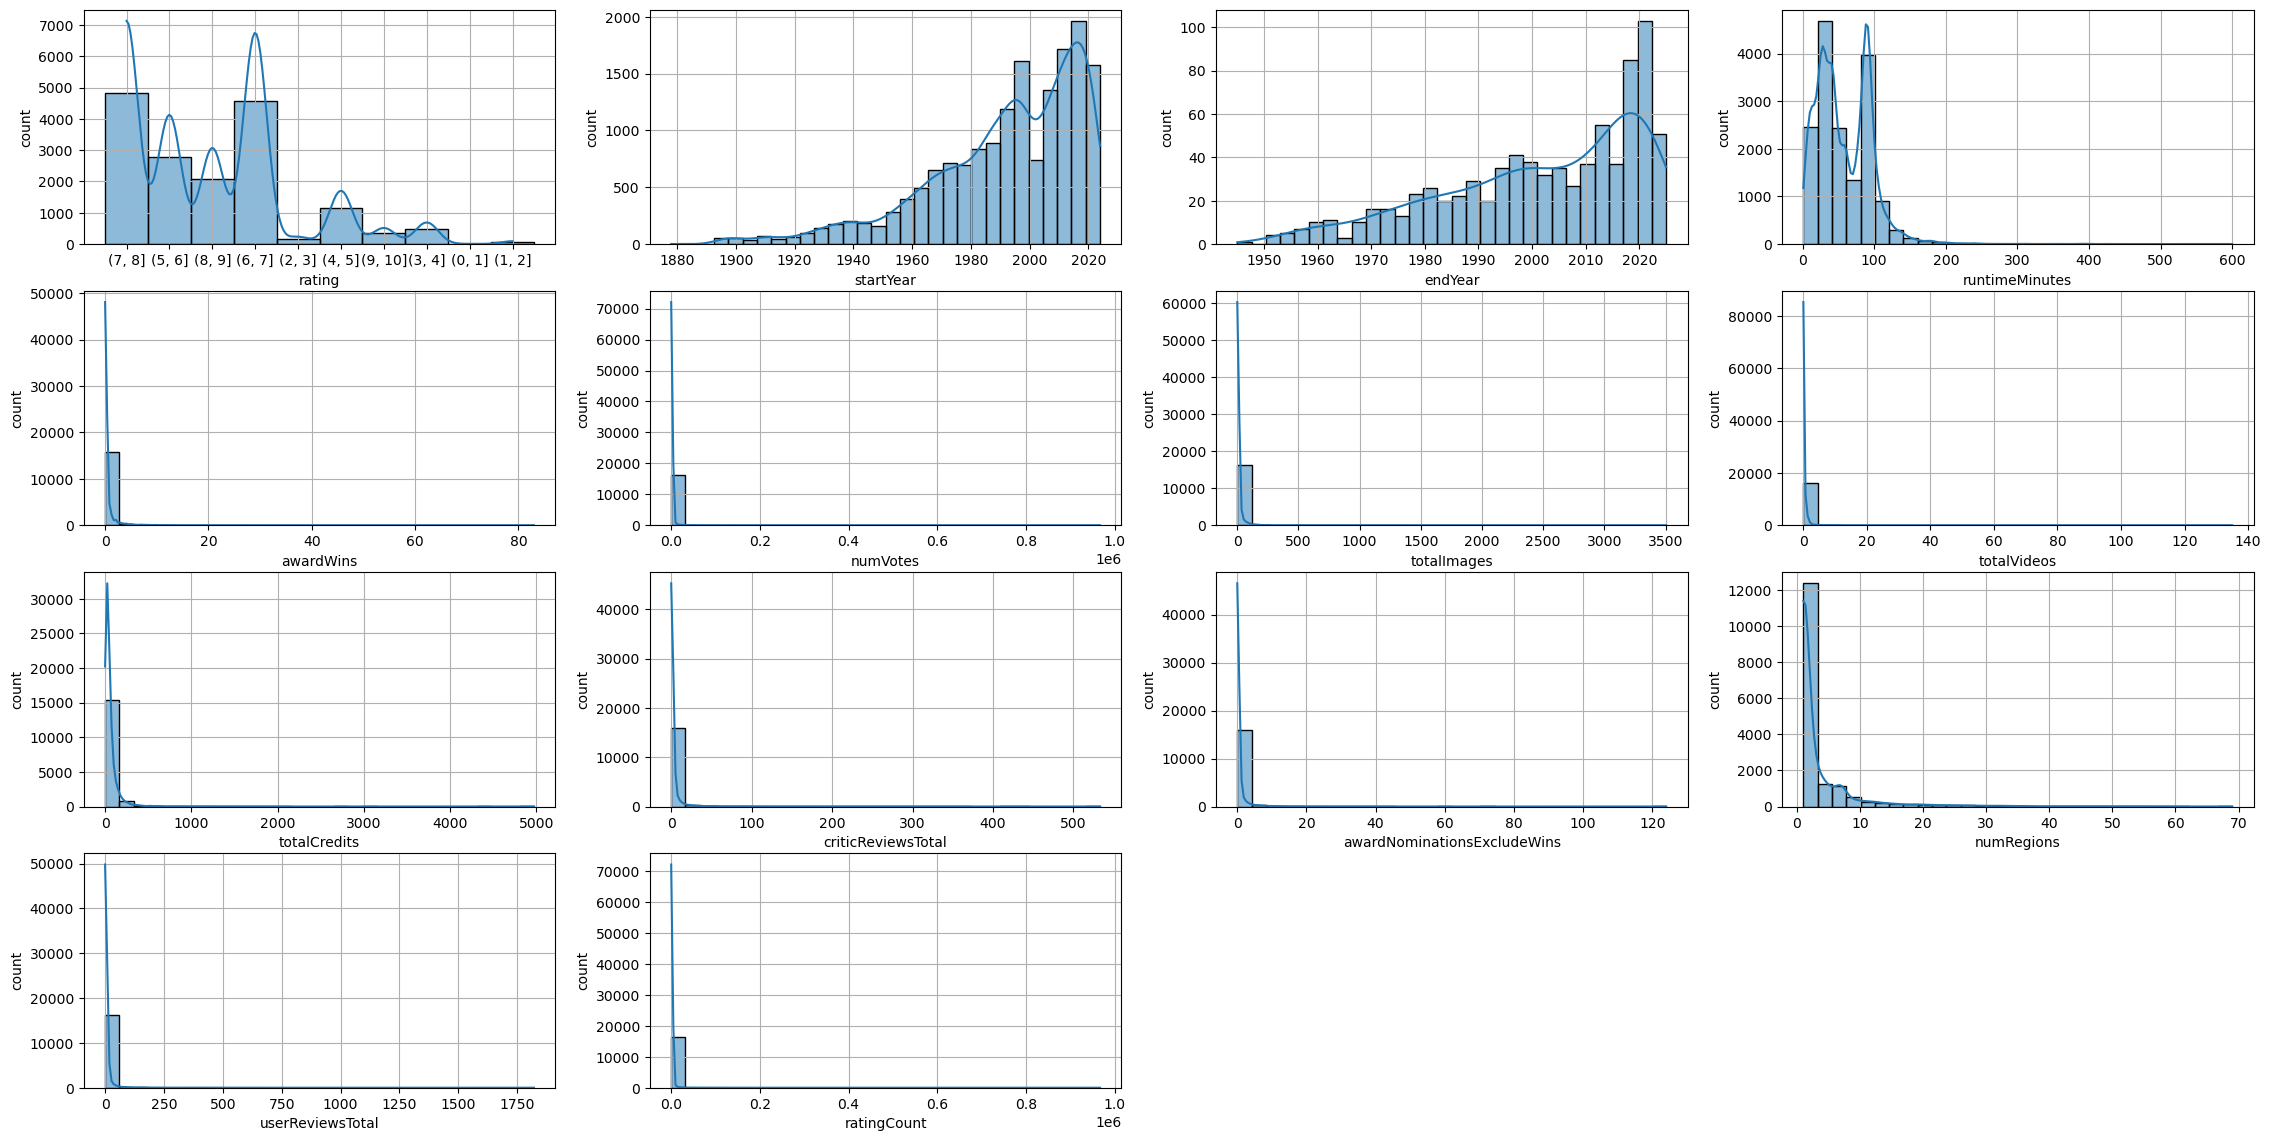

In [30]:
variables = ['rating', 'startYear', 'endYear', 'runtimeMinutes', 'awardWins', 
                     'numVotes', 'totalImages', 'totalVideos', 'totalCredits','criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 
                      'userReviewsTotal', 'ratingCount']



# Loop through each column to plot histogram and box plot
plt.figure(figsize=(28, 14))
for i, col in enumerate(variables):
    plt.subplot(4, 4, i+1)

    # Histogram with KDE (Kernel Density Estimate)
    sns.histplot(df[col], kde=True, bins=30)
    # plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.grid(True)

In [31]:
df

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,titleType,awardNominationsExcludeWins,canHaveEpisodes,isRatable,isAdult,numRegions,userReviewsTotal,ratingCount,countryOfOrigin,genres
0,Neogenic Nightmare Chapter 3: Hydro-Man,"(7, 8]",1995,NaN,40.0,0,779,1,10,1,...,tvEpisode,0,False,True,False,1,0,781,[US],"Action,Adventure,Animation"
1,Looping,"(5, 6]",1982,NaN,28.0,0,11,1,10,1,...,videoGame,0,False,True,False,1,0,11,[XWG],Action
2,Idealnaya para,"(5, 6]",1992,NaN,90.0,0,38,1,10,1,...,movie,0,False,True,False,1,1,38,[RU],Comedy
3,MasterChef Celebrity México,"(5, 6]",2021,NaN,30.0,0,15,1,10,22,...,tvSeries,0,True,True,False,1,0,15,[MX],Reality-TV
4,Seutateueob,"(7, 8]",2020,2020.0,80.0,1,15718,1,10,347,...,tvSeries,1,True,True,False,32,452,15746,[KR],"Comedy,Drama,Romance"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16426,Caprices,"(5, 6]",1942,NaN,90.0,0,73,1,10,4,...,movie,0,False,True,False,14,4,73,[FR],Comedy
16427,Haar Jeet,"(4, 5]",1990,NaN,90.0,0,15,1,10,2,...,movie,0,False,True,False,1,1,15,[IN],"Action,Drama,Thriller"
16428,Kotigobba 3,"(5, 6]",2021,NaN,140.0,0,2560,1,10,39,...,movie,5,False,True,False,5,49,2560,[IN],"Action,Drama,Romance"
16429,Ator l'invincibile,"(3, 4]",1982,NaN,90.0,0,3011,1,10,52,...,movie,0,False,True,False,26,58,3012,[IT],"Action,Adventure,Fantasy"


In [32]:
df.to_csv("train_1.csv", index=False)

In [33]:
df.rating.value_counts()

rating
(7, 8]     4819
(6, 7]     4564
(5, 6]     2786
(8, 9]     2070
(4, 5]     1151
(3, 4]      466
(9, 10]     346
(2, 3]      154
(1, 2]       62
(0, 1]        5
Name: count, dtype: int64

In [34]:
# Sample DataFrame with categorical rating ranges
df_rating = pd.DataFrame({
    'rating': ['(7, 8]', '(6, 7]', '(5, 6]', '(8, 9]', '(4, 5]', '(3, 4]', '(9, 10]', '(2, 3]', '(1, 2]', '(0, 1]'],
    'count': [4822, 4565, 2789, 2071, 1151, 466, 346, 154, 62, 5]
})

# Create a dictionary to map each range to its midpoint
rating_to_float = {
    '(7, 8]': 7.5,
    '(6, 7]': 6.5,
    '(5, 6]': 5.5,
    '(8, 9]': 8.5,
    '(4, 5]': 4.5,
    '(3, 4]': 3.5,
    '(9, 10]': 9.5,
    '(2, 3]': 2.5,
    '(1, 2]': 1.5,
    '(0, 1]': 0.5
}

# Replace categorical ratings with float values
df['rating'] = df['rating'].replace(rating_to_float).astype(float)

# Display the updated DataFrame
print(df_rating)

    rating  count
0   (7, 8]   4822
1   (6, 7]   4565
2   (5, 6]   2789
3   (8, 9]   2071
4   (4, 5]   1151
5   (3, 4]    466
6  (9, 10]    346
7   (2, 3]    154
8   (1, 2]     62
9   (0, 1]      5


C:\Users\hiend\AppData\Local\Temp\ipykernel_11288\1816977320.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['rating'] = df['rating'].replace(rating_to_float).astype(float)


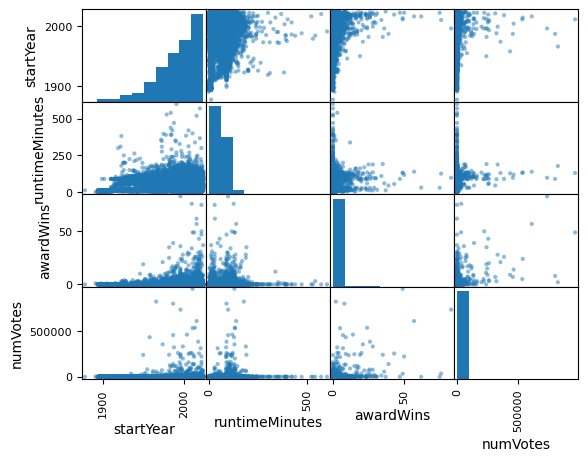

In [35]:
pd.plotting.scatter_matrix(df[['startYear', 'runtimeMinutes', 'awardWins', 'numVotes']])
plt.show()

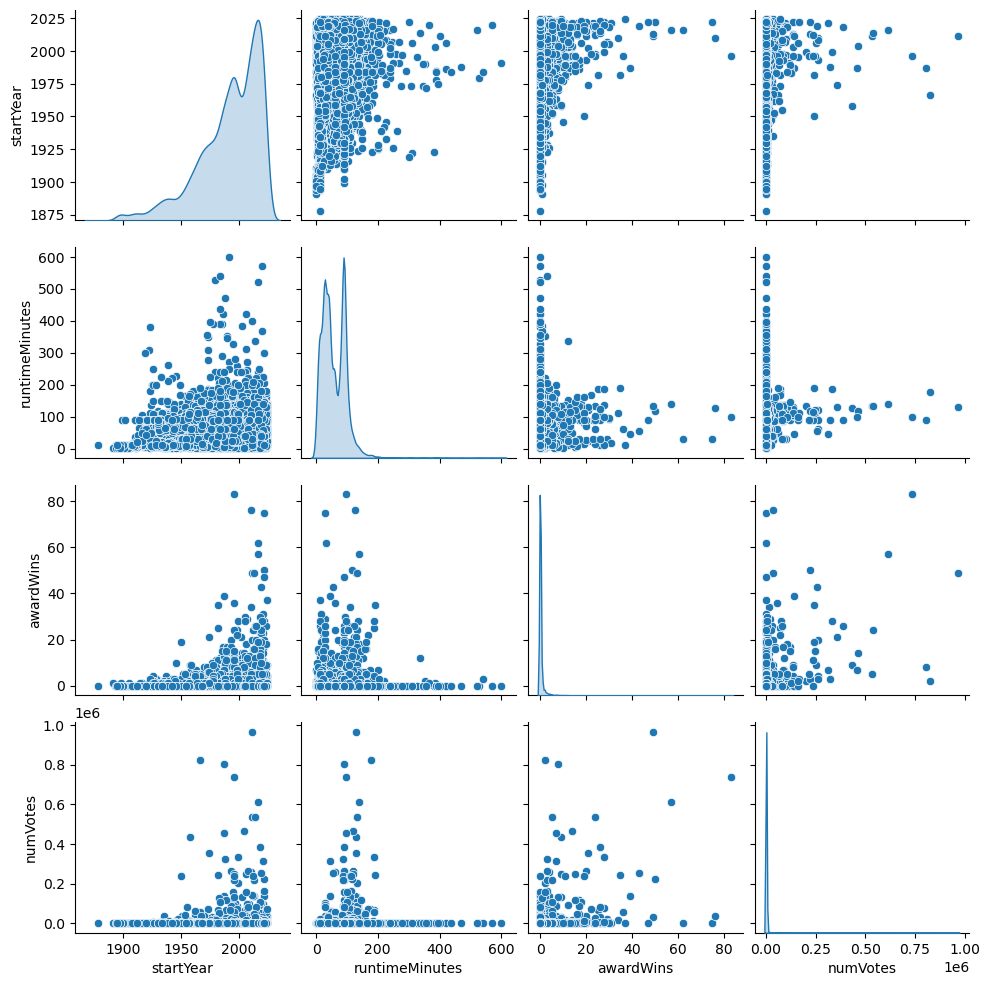

In [36]:
sns.pairplot(df[['startYear', 'runtimeMinutes', 'awardWins', 'numVotes']], diag_kind="kde")
plt.show()

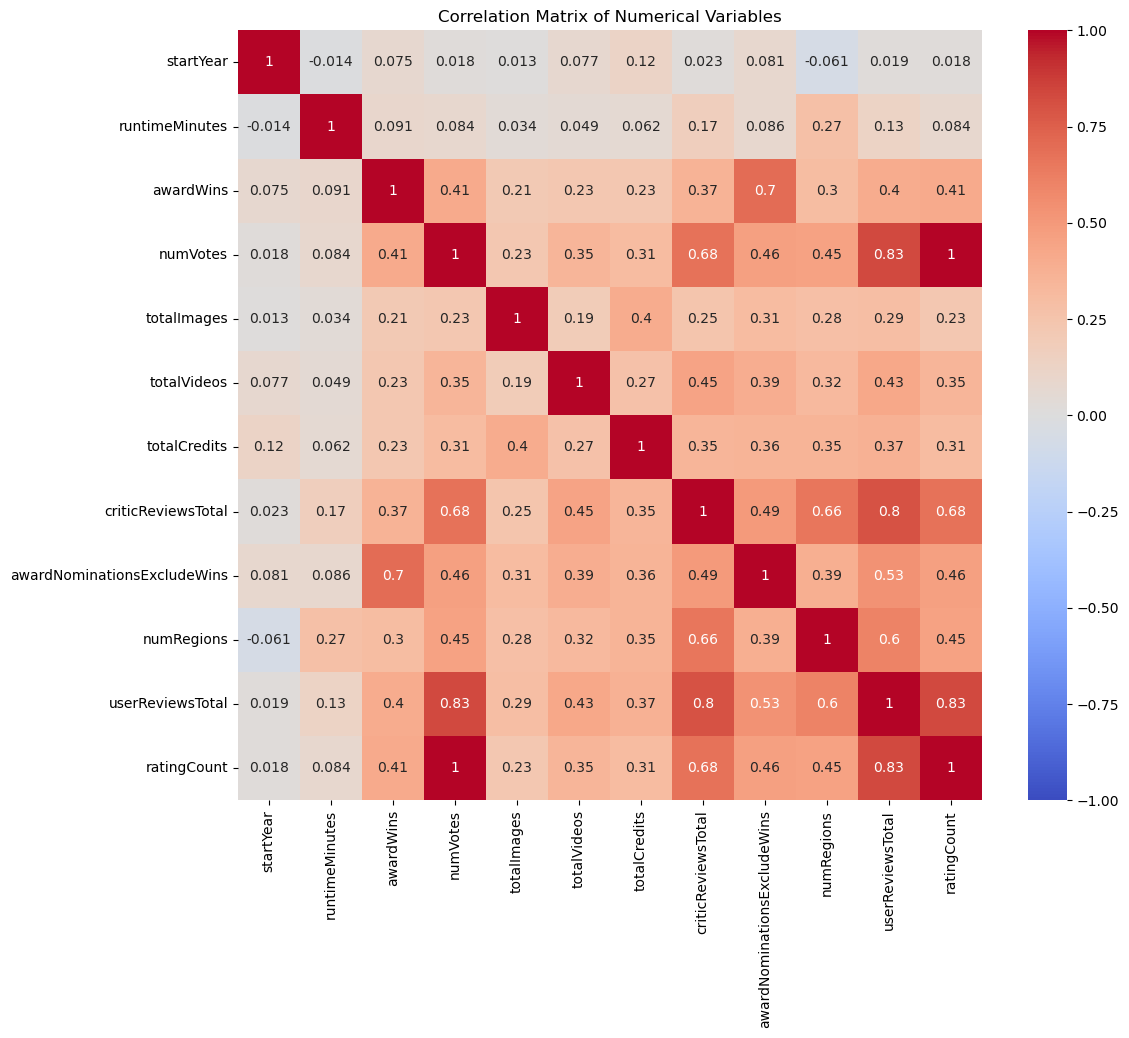

Highly Correlated Variable Pairs (Threshold > 0.8):
         Variable 1        Variable 2  Correlation
0          numVotes  userReviewsTotal     0.832537
1          numVotes       ratingCount     1.000000
2  userReviewsTotal          numVotes     0.832537
3  userReviewsTotal       ratingCount     0.832594
4       ratingCount          numVotes     1.000000
5       ratingCount  userReviewsTotal     0.832594


In [37]:
# Select only numerical columns for correlation analysis
numerical_columns = ['startYear', 'runtimeMinutes', 'awardWins', 
                     'numVotes', 'totalImages', 'totalVideos', 'totalCredits','criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 
                      'userReviewsTotal', 'ratingCount',]
df_numeric = df[numerical_columns]

# Step 1: Calculate the correlation matrix
correlation_matrix = df_numeric.corr(method="pearson")

# Step 2: Visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

# Step 3: Identify highly correlated pairs
threshold = 0.8  # Set the threshold for high correlation
high_corr_pairs = [(col1, col2, correlation_matrix.loc[col1, col2]) 
                   for col1 in correlation_matrix.columns 
                   for col2 in correlation_matrix.columns 
                   if col1 != col2 and abs(correlation_matrix.loc[col1, col2]) > threshold]

# Display highly correlated pairs
high_corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=["Variable 1", "Variable 2", "Correlation"])
print("Highly Correlated Variable Pairs (Threshold > 0.8):")
print(high_corr_pairs_df)

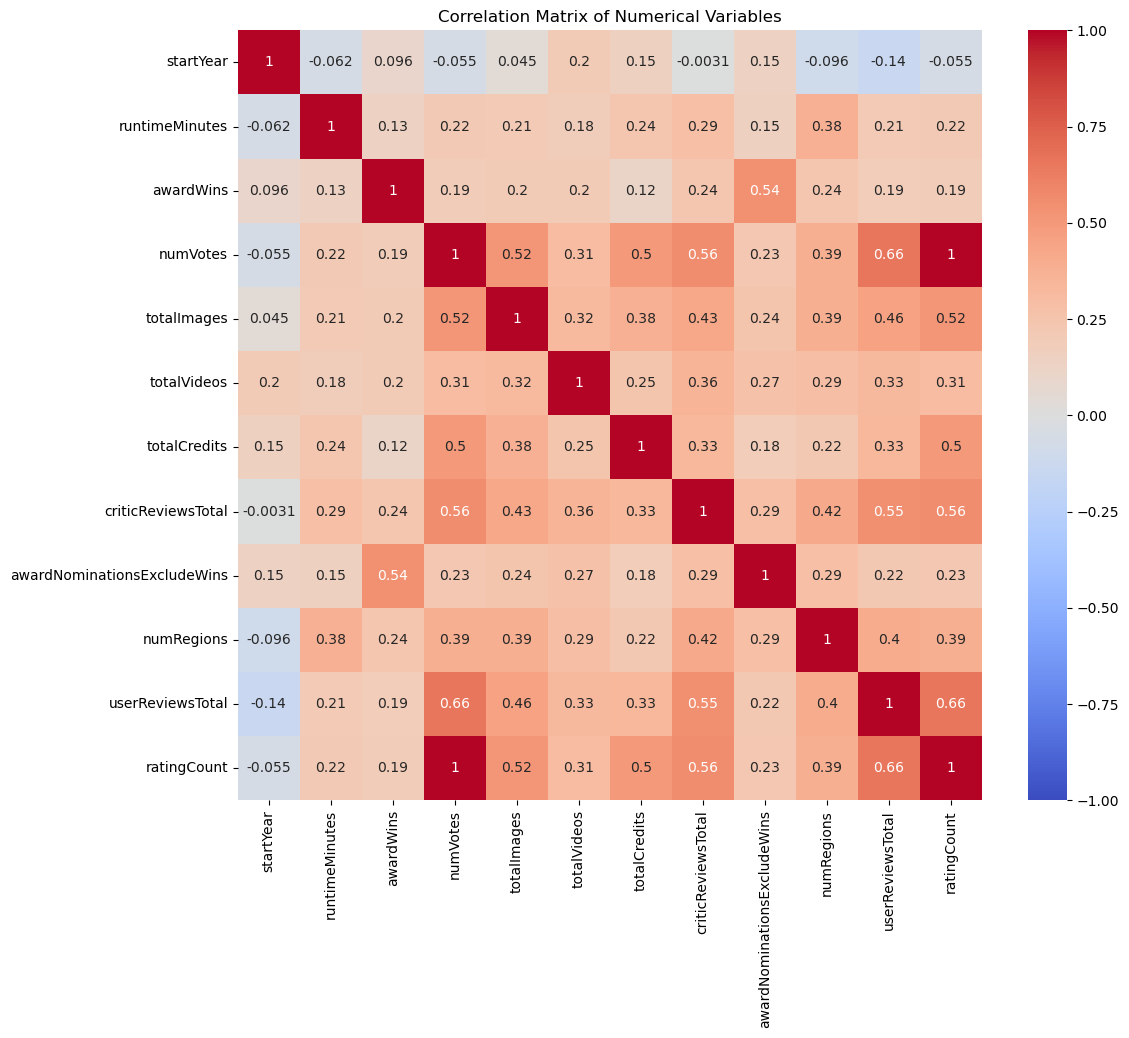

Highly Correlated Variable Pairs (Threshold > 0.8):
    Variable 1   Variable 2  Correlation
0     numVotes  ratingCount     0.999968
1  ratingCount     numVotes     0.999968


In [38]:
# Select only numerical columns for correlation analysis
numerical_columns = ['startYear', 'runtimeMinutes', 'awardWins', 
                     'numVotes', 'totalImages', 'totalVideos', 'totalCredits','criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 
                      'userReviewsTotal', 'ratingCount',]
df_numeric = df[numerical_columns]

# Step 1: Calculate the correlation matrix
correlation_matrix = df_numeric.corr(method="spearman")

# Step 2: Visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

# Step 3: Identify highly correlated pairs
threshold = 0.8  # Set the threshold for high correlation
high_corr_pairs = [(col1, col2, correlation_matrix.loc[col1, col2]) 
                   for col1 in correlation_matrix.columns 
                   for col2 in correlation_matrix.columns 
                   if col1 != col2 and abs(correlation_matrix.loc[col1, col2]) > threshold]

# Display highly correlated pairs
high_corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=["Variable 1", "Variable 2", "Correlation"])
print("Highly Correlated Variable Pairs (Threshold > 0.8):")
print(high_corr_pairs_df)

Pairplot (scatter matrix)

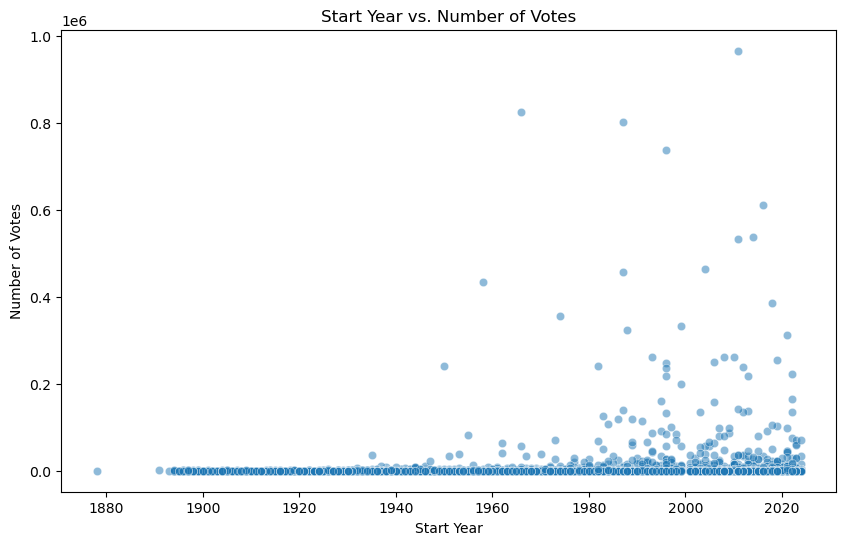

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='startYear', y='numVotes', alpha=0.5)
plt.title('Start Year vs. Number of Votes')
plt.xlabel('Start Year')
plt.ylabel('Number of Votes')
plt.show()


-> newer films receive more votes -> viewer engagement has grown over time, likely due to increased access and popularity of online platforms.

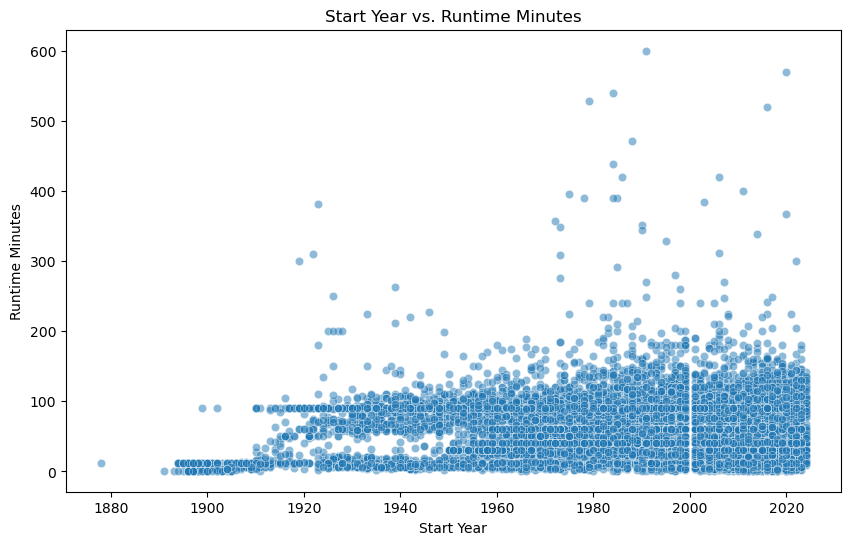

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='startYear', y='runtimeMinutes', alpha=0.5)
plt.title('Start Year vs. Runtime Minutes')
plt.xlabel('Start Year')
plt.ylabel('Runtime Minutes')
plt.show()

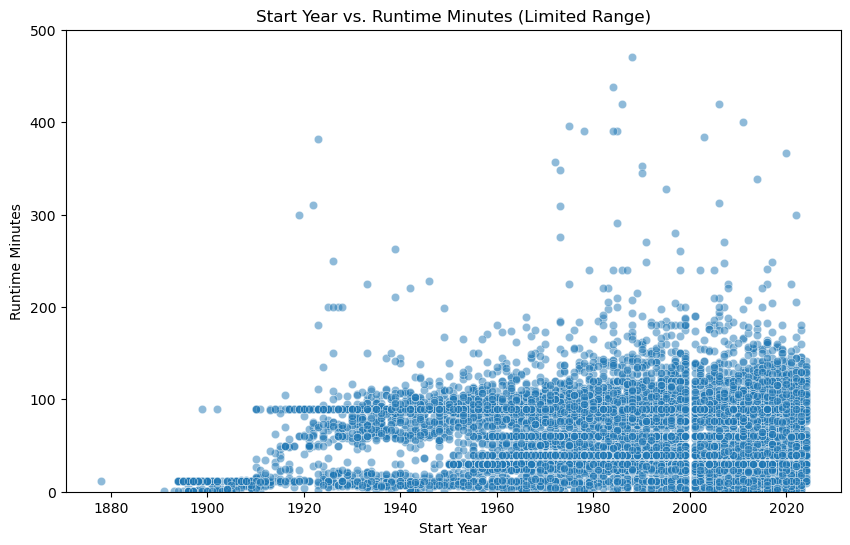

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='startYear', y='runtimeMinutes', alpha=0.5)
plt.ylim(0, 500)  # Set y-axis limit
plt.title('Start Year vs. Runtime Minutes (Limited Range)')
plt.xlabel('Start Year')
plt.ylabel('Runtime Minutes')
plt.show()

In [42]:
df['startYear'] == 2000

0        False
1        False
2        False
3        False
4        False
         ...  
16426    False
16427    False
16428    False
16429    False
16430    False
Name: startYear, Length: 16423, dtype: bool

The plot shows a concentration of films with shorter runtimes in the earlier years, with an increase in runtime variation over time, especially after the 1980s.

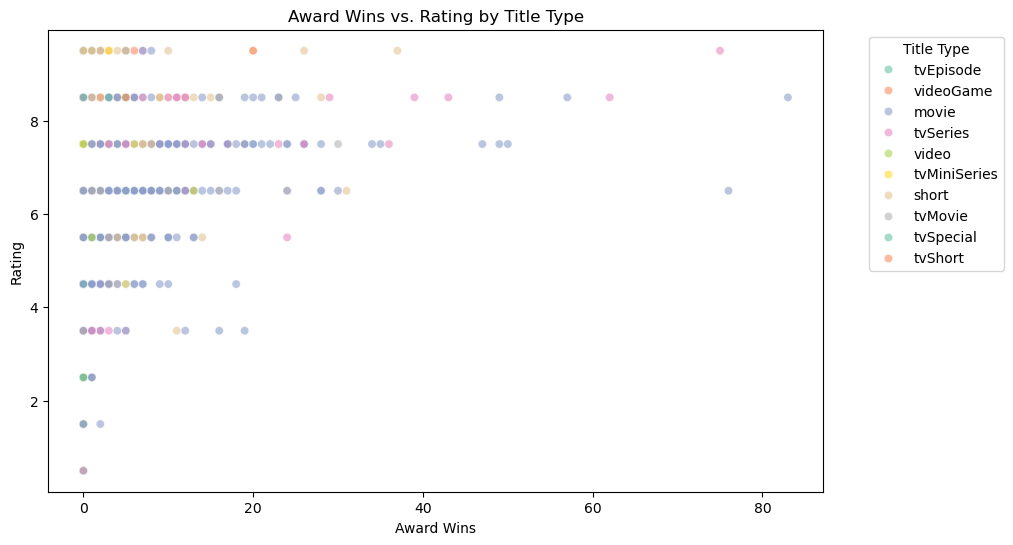

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='awardWins', y='rating', hue='titleType', palette='Set2', alpha=0.6)
plt.title("Award Wins vs. Rating by Title Type")
plt.xlabel("Award Wins")
plt.ylabel("Rating")
plt.legend(title="Title Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

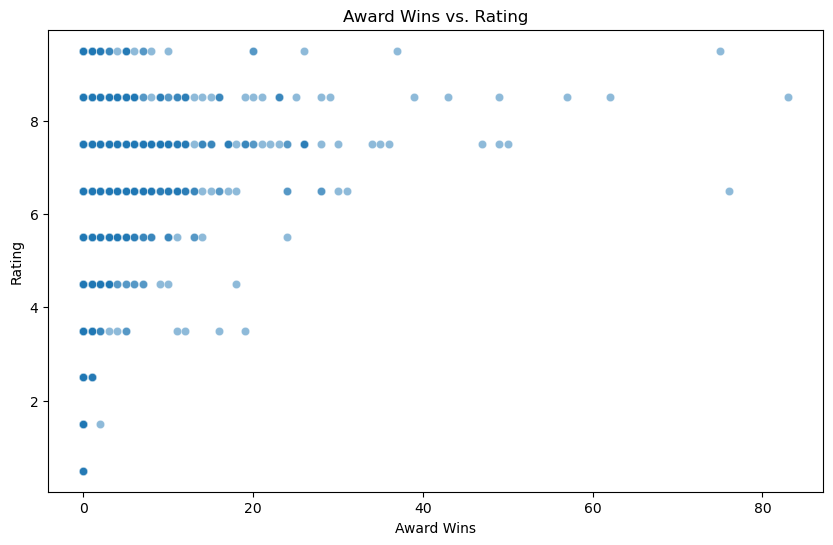

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='awardWins', y='rating', alpha=0.5)
plt.title('Award Wins vs. Rating')
plt.xlabel('Award Wins')
plt.ylabel('Rating')
plt.show()

 -> many films with high ratings (around 8–10) but with few or no awards -> a high rating doesn't necessarily correlate with a large number of awards

In [45]:
df[['runtimeMinutes', 'genres']].head()

,runtimeMinutes,genres
0,40.0,"Action,Adventure,Animation"
1,28.0,Action
2,90.0,Comedy
3,30.0,Reality-TV
4,80.0,"Comedy,Drama,Romance"


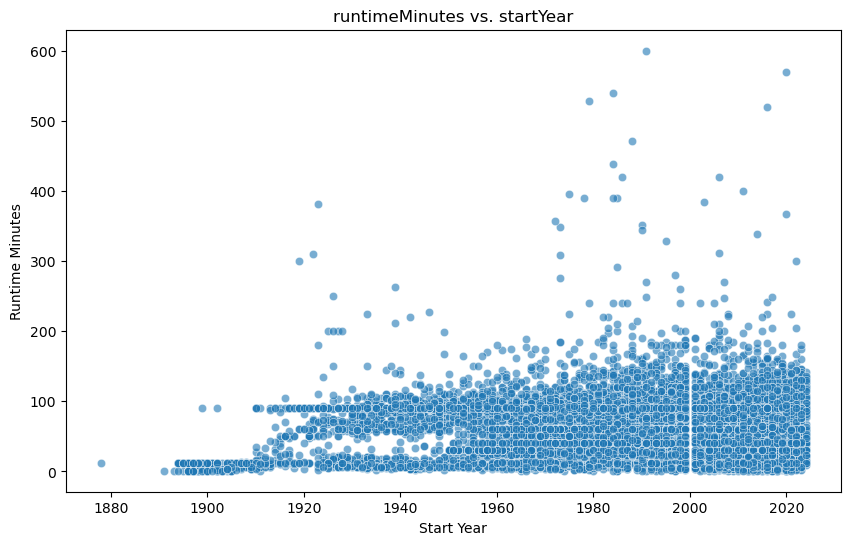

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='startYear', y='runtimeMinutes', alpha=0.6)
plt.title('runtimeMinutes vs. startYear')
plt.xlabel('Start Year')
plt.ylabel('Runtime Minutes')
plt.show()

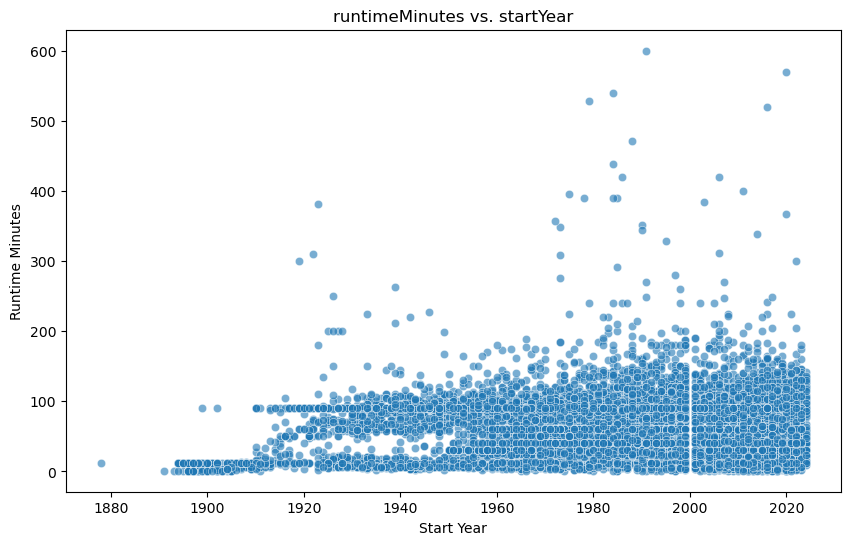

In [47]:
df_filtered = df[df['runtimeMinutes'] < 1000]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='startYear', y='runtimeMinutes', alpha=0.6)
plt.title('runtimeMinutes vs. startYear')
plt.xlabel('Start Year')
plt.ylabel('Runtime Minutes')
plt.show()

-> modern films and shows have longer runtimes than older films

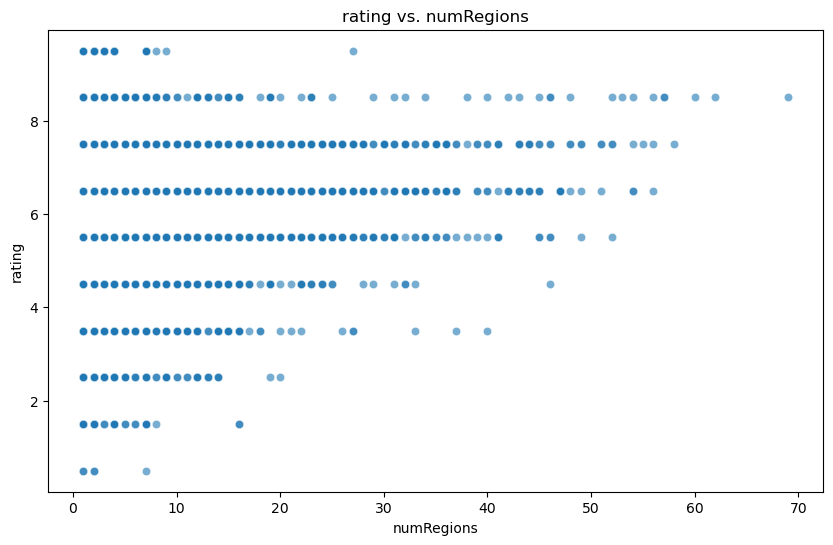

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='numRegions', y='rating', alpha=0.6)
plt.title('rating vs. numRegions')
plt.xlabel('numRegions')
plt.ylabel('rating')
plt.show()

In [49]:
df.head()

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,titleType,awardNominationsExcludeWins,canHaveEpisodes,isRatable,isAdult,numRegions,userReviewsTotal,ratingCount,countryOfOrigin,genres
0,Neogenic Nightmare Chapter 3: Hydro-Man,7.5,1995,NaN,40.0,0,779,1,10,1,...,tvEpisode,0,False,True,False,1,0,781,[US],"Action,Adventure,Animation"
1,Looping,5.5,1982,NaN,28.0,0,11,1,10,1,...,videoGame,0,False,True,False,1,0,11,[XWG],Action
2,Idealnaya para,5.5,1992,NaN,90.0,0,38,1,10,1,...,movie,0,False,True,False,1,1,38,[RU],Comedy
3,MasterChef Celebrity México,5.5,2021,NaN,30.0,0,15,1,10,22,...,tvSeries,0,True,True,False,1,0,15,[MX],Reality-TV
4,Seutateueob,7.5,2020,2020.0,80.0,1,15718,1,10,347,...,tvSeries,1,True,True,False,32,452,15746,[KR],"Comedy,Drama,Romance"


In [50]:
df.dtypes

originalTitle                   object
rating                         float64
startYear                        int64
endYear                        float64
runtimeMinutes                 float64
awardWins                        int32
numVotes                         int64
worstRating                      int64
bestRating                       int64
totalImages                      int64
totalVideos                      int64
totalCredits                     int64
criticReviewsTotal               int64
titleType                       object
awardNominationsExcludeWins      int64
canHaveEpisodes                   bool
isRatable                         bool
isAdult                           bool
numRegions                       int64
userReviewsTotal                 int64
ratingCount                      int64
countryOfOrigin                 object
genres                          object
dtype: object

In [51]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 16423 entries, 0 to 16430
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16423 non-null  object 
 1   rating                       16423 non-null  float64
 2   startYear                    16423 non-null  int64  
 3   endYear                      812 non-null    float64
 4   runtimeMinutes               16423 non-null  float64
 5   awardWins                    16423 non-null  int32  
 6   numVotes                     16423 non-null  int64  
 7   worstRating                  16423 non-null  int64  
 8   bestRating                   16423 non-null  int64  
 9   totalImages                  16423 non-null  int64  
 10  totalVideos                  16423 non-null  int64  
 11  totalCredits                 16423 non-null  int64  
 12  criticReviewsTotal           16423 non-null  int64  
 13  titleType            

Missing value

In [52]:
df.isnull().any()

originalTitle                  False
rating                         False
startYear                      False
endYear                         True
runtimeMinutes                 False
awardWins                      False
numVotes                       False
worstRating                    False
bestRating                     False
totalImages                    False
totalVideos                    False
totalCredits                   False
criticReviewsTotal             False
titleType                      False
awardNominationsExcludeWins    False
canHaveEpisodes                False
isRatable                      False
isAdult                        False
numRegions                     False
userReviewsTotal               False
ratingCount                    False
countryOfOrigin                False
genres                         False
dtype: bool

In [53]:
df.isnull().sum()

originalTitle                      0
rating                             0
startYear                          0
endYear                        15611
runtimeMinutes                     0
awardWins                          0
numVotes                           0
worstRating                        0
bestRating                         0
totalImages                        0
totalVideos                        0
totalCredits                       0
criticReviewsTotal                 0
titleType                          0
awardNominationsExcludeWins        0
canHaveEpisodes                    0
isRatable                          0
isAdult                            0
numRegions                         0
userReviewsTotal                   0
ratingCount                        0
countryOfOrigin                    0
genres                             0
dtype: int64

In [54]:
df.drop(columns=['originalTitle', 'endYear','ratingCount', 'isRatable','worstRating', 'bestRating', ], inplace=True)

In [55]:
df.to_csv("train_clean.csv", index=False)

In [56]:
df.isnull().sum()

rating                         0
startYear                      0
runtimeMinutes                 0
awardWins                      0
numVotes                       0
totalImages                    0
totalVideos                    0
totalCredits                   0
criticReviewsTotal             0
titleType                      0
awardNominationsExcludeWins    0
canHaveEpisodes                0
isAdult                        0
numRegions                     0
userReviewsTotal               0
countryOfOrigin                0
genres                         0
dtype: int64

In [57]:
# Split the genres column into separate columns
genres_split = df['genres'].str.split(',', expand=True)

# Rename the new columns for clarity
genres_split.columns = [f'genre_{i+1}' for i in range(genres_split.shape[1])]

# Concatenate the new columns with the original dataframe
df_with_genres = pd.concat([df, genres_split], axis=1)



In [58]:
# Display the resulting dataframe
df_with_genres.head()

,rating,startYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,titleType,awardNominationsExcludeWins,canHaveEpisodes,isAdult,numRegions,userReviewsTotal,countryOfOrigin,genres,genre_1,genre_2,genre_3
0,7.5,1995,40.0,0,779,1,0,21,1,tvEpisode,0,False,False,1,0,[US],"Action,Adventure,Animation",Action,Adventure,Animation
1,5.5,1982,28.0,0,11,1,0,1,0,videoGame,0,False,False,1,0,[XWG],Action,Action,None,None
2,5.5,1992,90.0,0,38,1,0,24,0,movie,0,False,False,1,1,[RU],Comedy,Comedy,None,None
3,5.5,2021,30.0,0,15,22,0,56,0,tvSeries,0,True,False,1,0,[MX],Reality-TV,Reality-TV,None,None
4,7.5,2020,80.0,1,15718,347,2,47,4,tvSeries,1,True,False,32,452,[KR],"Comedy,Drama,Romance",Comedy,Drama,Romance


In [59]:
# Combine all genres into a single column for counting
all_genres = pd.concat([df_with_genres['genre_1'], df_with_genres['genre_2'], df_with_genres['genre_3']], axis=0)

# Drop NaN values (genres that don't exist in some rows)
all_genres = all_genres.dropna()

# Count the frequency of each genre
genre_counts = all_genres.value_counts()

# Display the genre statistics
print(genre_counts)

Drama          6172
Comedy         4838
Short          2462
Action         1955
Documentary    1833
Crime          1741
Adventure      1609
Animation      1487
Romance        1382
Family         1226
Thriller        785
Horror          688
Fantasy         656
Mystery         644
Music           554
Sci-Fi          449
Adult           433
Reality-TV      365
History         355
Talk-Show       338
Western         303
Biography       277
Game-Show       250
Sport           229
Musical         228
War             211
News            158
Film-Noir        27
Name: count, dtype: int64


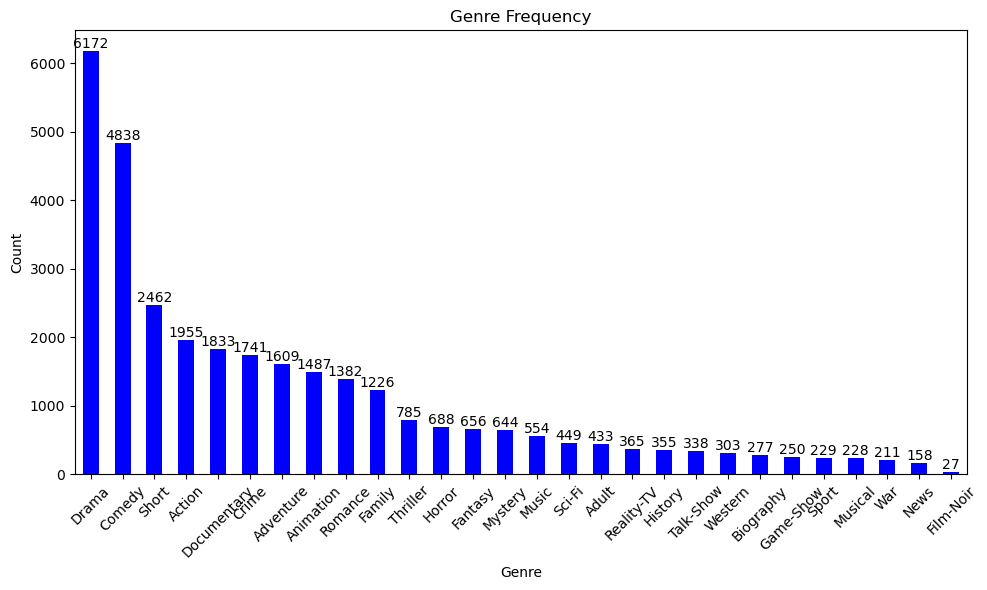

In [60]:
# Plot the genre counts
plt.figure(figsize=(10, 6))
bar_plot = genre_counts.plot(kind='bar', color='blue')

# Add counts on top of each bar
for bar in bar_plot.patches:
    bar_plot.annotate(
        format(bar.get_height(), '.0f'),  # Format the count as an integer
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),  # Position at the center top of each bar
        ha='center',  # Horizontal alignment
        va='bottom'   # Vertical alignment
    )

# Add labels and title
plt.title("Genre Frequency")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
df_with_genres.columns

Index(['rating', 'startYear', 'runtimeMinutes', 'awardWins', 'numVotes',
       'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal',
       'titleType', 'awardNominationsExcludeWins', 'canHaveEpisodes',
       'isAdult', 'numRegions', 'userReviewsTotal', 'countryOfOrigin',
       'genres', 'genre_1', 'genre_2', 'genre_3'],
      dtype='object')

In [62]:
df_with_genres['genre_1'].unique()

array(['Action', 'Comedy', 'Reality-TV', 'Documentary', 'Drama',
       'Animation', 'Sport', 'Family', 'Short', 'Crime', 'Western',
       'Adult', 'Talk-Show', 'Adventure', 'Game-Show', 'Fantasy',
       'Horror', 'Thriller', 'Music', 'Biography', 'Romance', 'Sci-Fi',
       'Mystery', 'Musical', 'History', 'News', 'War', 'Film-Noir'],
      dtype=object)

In [63]:
df_with_genres[['genre_1', 'genre_2', 'genre_3']].isnull().sum()

genre_1        0
genre_2     6308
genre_3    11306
dtype: int64

In [64]:
# Initialize CountVectorizer
vectorizer = CountVectorizer(tokenizer=lambda x: x.split(','), binary=True)

# Fit and transform the combined genres
genre_matrix = vectorizer.fit_transform(df['genres_combined'])

# Convert the sparse matrix to a DataFrame
genre_df = pd.DataFrame(genre_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Concatenate the vectorized genres with the original DataFrame
df_with_genres_vectorized = pd.concat([df, genre_df], axis=1)

# Drop the original genres columns if not needed
df_with_genres_vectorized = df_with_genres_vectorized.drop(columns=['genres_combined', 'genre_1', 'genre_2', 'genre_3'], errors='ignore')

# Display the resulting DataFrame
print(df_with_genres_vectorized.head())

KeyError: 'genres_combined'

In [ ]:
df['countryOfOrigin'].unique

<bound method Series.unique of 0         [US]
1        [XWG]
2         [RU]
3         [MX]
4         [KR]
         ...  
16426     [FR]
16427     [IN]
16428     [IN]
16429     [IT]
16430     [IN]
Name: countryOfOrigin, Length: 16431, dtype: object>

In [66]:

# 1. Ensure all country entries are strings and clean
df['countryOfOrigin'] = df['countryOfOrigin'].astype(str).str.strip("[]").str.replace("'", "")

# 2. Split the countries into a list
df['countryOfOrigin'] = df['countryOfOrigin'].str.split(',')

# 3. Explode the list into individual countries for counting
all_countries = df['countryOfOrigin'].explode()

# 4. Clean whitespace and drop NaN values
all_countries = all_countries.str.strip().dropna()

# 5. Count the occurrences of each country
country_counts = all_countries.value_counts()

# 6. Display the results
print(country_counts)


countryOfOrigin
US    7134
GB    1775
JP     846
FR     826
CA     621
      ... 
EH       1
NE       1
PR       1
VA       1
GA       1
Name: count, Length: 153, dtype: int64


In [69]:
# Display the top 20 countries
top_20_countries = country_counts.head(10)
top_20_countries

countryOfOrigin
US    7134
GB    1775
JP     846
FR     826
CA     621
IN     616
DE     502
IT     422
ES     325
AU     315
Name: count, dtype: int64

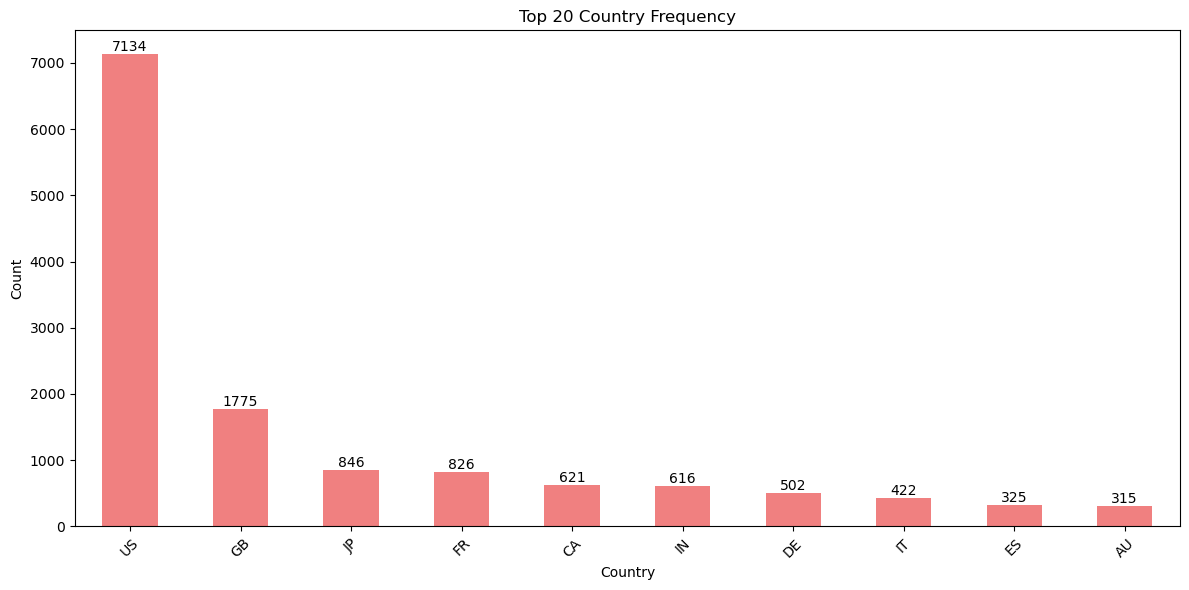

In [71]:
# Plot only the top 20 countries
top_20_countries = country_counts.head(10)

plt.figure(figsize=(12, 6))
bar_plot = top_20_countries.plot(kind='bar', color='lightcoral')

# Add counts on top of each bar
for bar in bar_plot.patches:
    bar_plot.annotate(
        format(bar.get_height(), '.0f'),  # Format the count as an integer
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),  # Position at the center top of each bar
        ha='center',  # Horizontal alignment
        va='bottom'   # Vertical alignment
    )

# Add labels and title
plt.title("Top 20 Country Frequency")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
df.countryOfOrigin.value_counts()

countryOfOrigin
[US]                6677
[GB]                1539
[JP]                 793
[IN]                 597
[FR]                 546
                    ... 
[FR,   IT,   ES]       1
[FI,   EE]             1
[RO,   RS,   BE]       1
[US,   CA,   GB]       1
[ME]                   1
Name: count, Length: 715, dtype: int64